# Import

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import seaborn as sns
import warnings
import os
from scipy import stats
import folium
from folium.plugins import HeatMap
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
import time

warnings.filterwarnings(action='ignore')
plt.rcParams["font.family"] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

c:\Users\USER\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Data Input

In [3]:
users = pd.read_excel('Data_2022\\PlusDR_Participant_Info.xlsx')

performance_raw = pd.read_excel('Data_2022\\PlusDR_Performance_Info.xlsx', sheet_name = None)

location_raw = pd.read_excel('Data_2022\\PlusDR_Location_Info.xlsx')

In [4]:
load_csv = [f for f in os.listdir('Data_2022\\PlusDR_Participant_Load_Data') if f.endswith('.csv')]

load_raw = {}

for file in load_csv:
    file_path = os.path.join('Data_2022\\PlusDR_Participant_Load_Data', file)
    
    df = pd.read_csv(file_path, index_col=0, skiprows=1)

    df_reset = df.reset_index()
    df_long = df_reset.melt(id_vars='date(kWh)', var_name='time', value_name='load_kWh')
    df_long['datetime'] = pd.to_datetime(df_long['date(kWh)'].astype(str) + ' ' + df_long['time'])
    df_long = df_long[['datetime', 'load_kWh']].sort_values('datetime').reset_index(drop=True)

    file_name = os.path.splitext(file)[0]

    threshold = users[users['Customer ID'] == int(file_name)]['Contract Power (kW)'].iloc[0] * 0.25 * 1.2
    df_long.loc[(df_long['load_kWh'] < 0) | (df_long['load_kWh'] > threshold), 'load_kWh'] = pd.NA

    load_raw[file_name] = df_long

# Raw-Load Data Analysis

In [5]:
summary_list = []

for name, df in load_raw.items():
    if df['load_kWh'].notna().sum() == 0:
        summary_list.append({
            'Customer ID': name,
            'start_date': None,
            'end_date': None,
            'missing_count': None,
            'missing_ratio': None,
            'short_gap_count': None,
            'long_gap_count': None,
            'short_gap_total_len': None,
            'long_gap_total_len': None
        })
        continue

    start_date = df.loc[df['load_kWh'].notna(), 'datetime'].min()
    end_date   = df.loc[df['load_kWh'].notna(), 'datetime'].max()

    mask = (df['datetime'] >= start_date) & (df['datetime'] <= end_date)
    target_df = df.loc[mask]

    missing_count = target_df['load_kWh'].isna().sum()
    total_points = len(target_df)
    missing_ratio = missing_count / total_points

    short_gap_count = 0
    long_gap_count = 0
    short_gap_total_len = 0
    long_gap_total_len = 0
    gap_length = 0

    for is_missing in target_df['load_kWh'].isna():
        if is_missing:
            gap_length += 1
        else:
            if gap_length > 0:
                if gap_length <= 12:
                    short_gap_count += 1
                    short_gap_total_len += gap_length
                else:
                    long_gap_count += 1
                    long_gap_total_len += gap_length
                gap_length = 0

    summary_list.append({
        'Customer ID': name,
        'start_date': start_date,
        'end_date': end_date,
        'missing_count': missing_count,
        'missing_ratio': round(missing_ratio, 4),
        'short_gap_count': short_gap_count,
        'short_gap_total_len': short_gap_total_len,
        'long_gap_count': long_gap_count,
        'long_gap_total_len': long_gap_total_len
    })

summary_df = pd.DataFrame(summary_list)

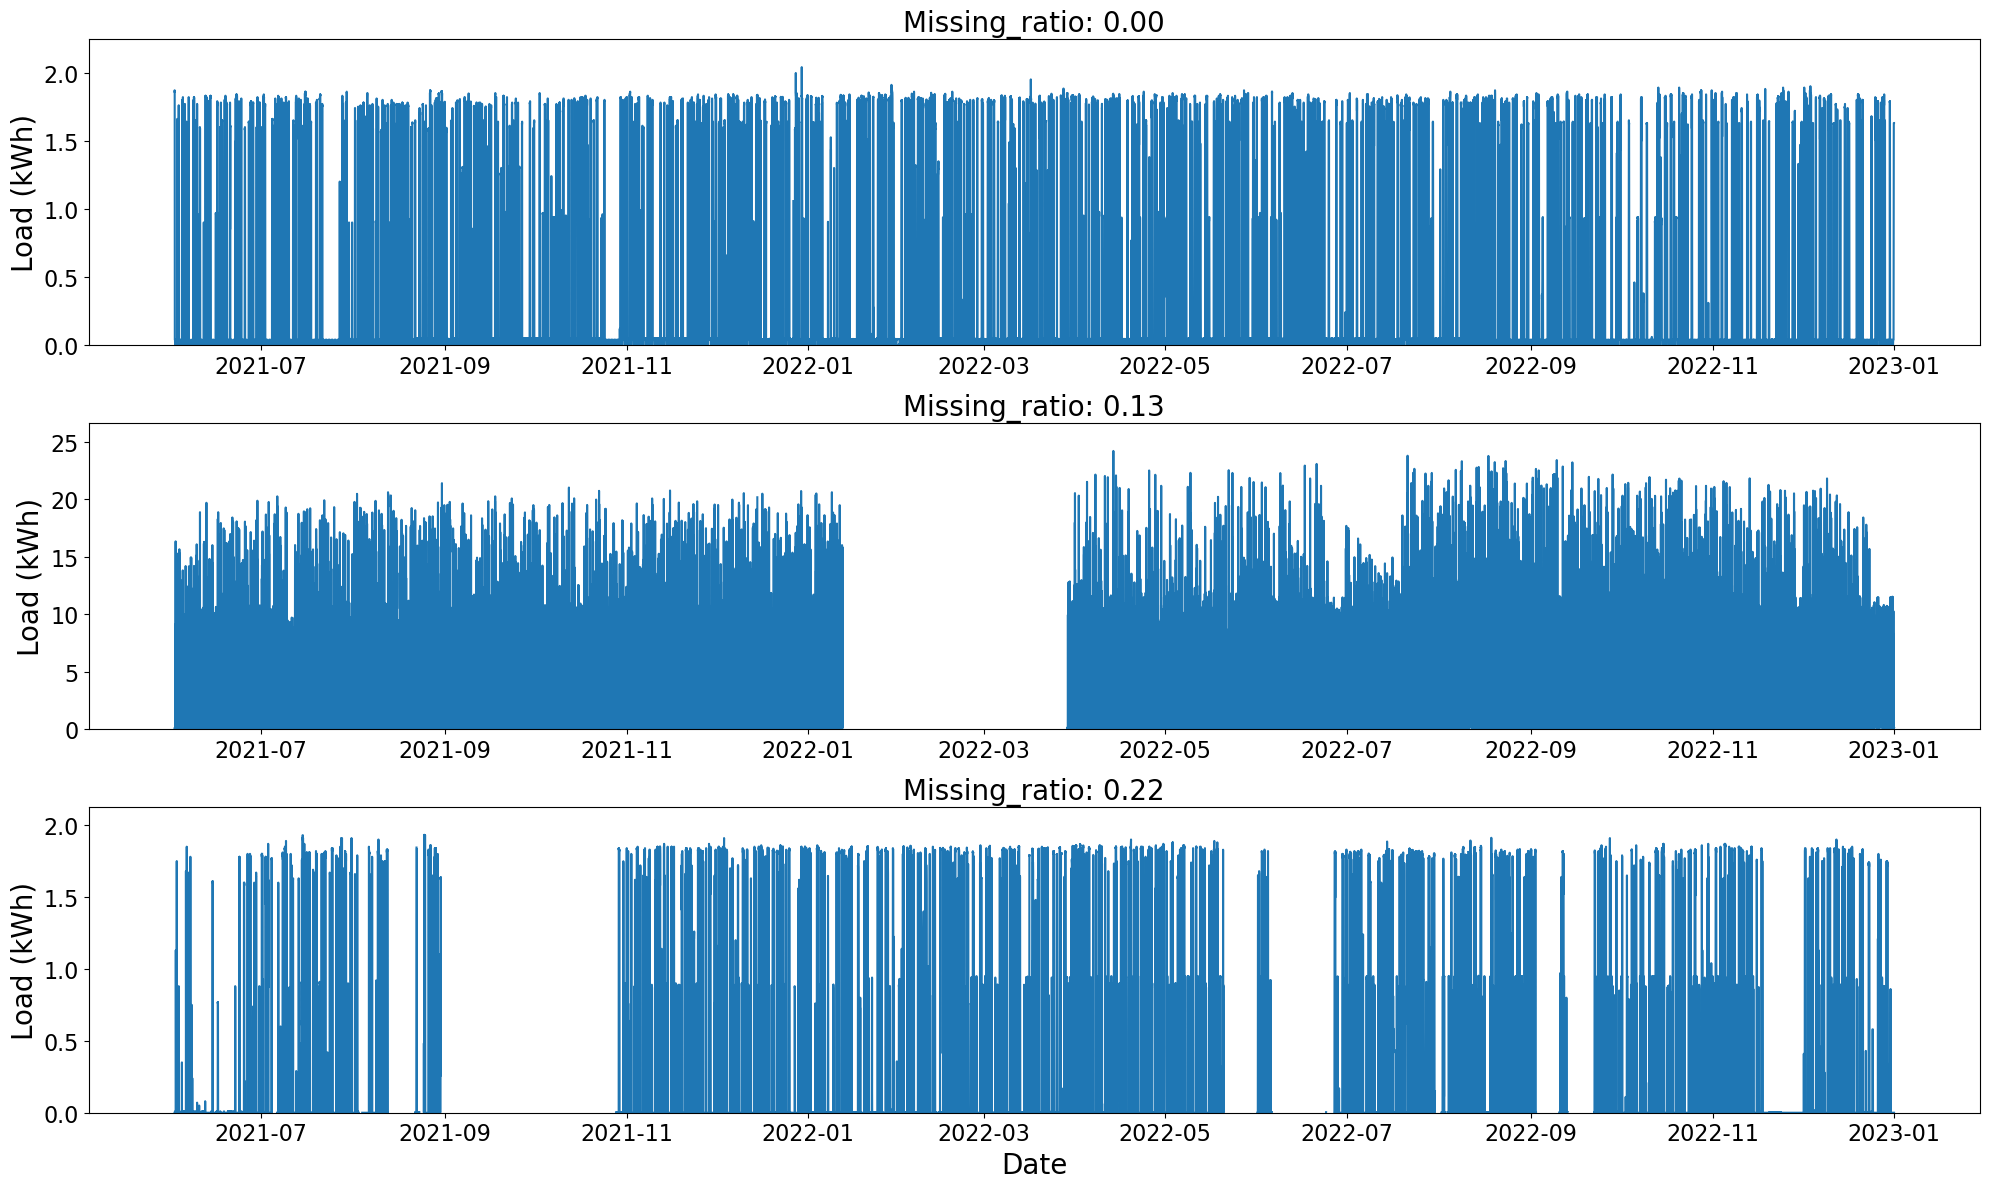

In [7]:
# Visualization of customer data with different missing value levels
low_missing = summary_df[summary_df["missing_ratio"] < 0.1].iloc[0]["Customer ID"]
mid_missing = summary_df[(summary_df["missing_ratio"] >= 0.1) & (summary_df["missing_ratio"] < 0.2)].iloc[0]["Customer ID"]
high_missing = summary_df[(summary_df["missing_ratio"] >= 0.2) & (summary_df["missing_ratio"] < 0.3)].iloc[0]["Customer ID"]

fig, axes = plt.subplots(3, 1, figsize=(20, 12))

# Customer with low missing values
customer_data = load_raw[low_missing]
axes[0].plot(customer_data['datetime'], customer_data['load_kWh'])
axes[0].set_title(f'Missing_ratio: {summary_df[summary_df["Customer ID"]==low_missing]["missing_ratio"].values[0]:.2f}', fontsize=20)
axes[0].set_ylabel('Load (kWh)', fontsize=20)
axes[0].set_ylim(0, customer_data['load_kWh'].max() * 1.1)
axes[0].tick_params(axis='both', which='major', labelsize=16)

# Customer with medium missing values
customer_data = load_raw[mid_missing]
axes[1].plot(customer_data['datetime'], customer_data['load_kWh'])
axes[1].set_title(f'Missing_ratio: {summary_df[summary_df["Customer ID"]==mid_missing]["missing_ratio"].values[0]:.2f}', fontsize=20)
axes[1].set_ylabel('Load (kWh)', fontsize=20)
axes[1].set_ylim(0, customer_data['load_kWh'].max() * 1.1)
axes[1].tick_params(axis='both', which='major', labelsize=16)

# Customer with high missing values
customer_data = load_raw[high_missing]
axes[2].plot(customer_data['datetime'], customer_data['load_kWh'])
axes[2].set_title(f'Missing_ratio: {summary_df[summary_df["Customer ID"]==high_missing]["missing_ratio"].values[0]:.2f}', fontsize=20)
axes[2].set_xlabel('Date', fontsize=20)
axes[2].set_ylabel('Load (kWh)', fontsize=20)
axes[2].set_ylim(0, customer_data['load_kWh'].max() * 1.1)
axes[2].tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.savefig("Figs/missing_ratio_customers.pdf", format="pdf", dpi=300)
plt.show()

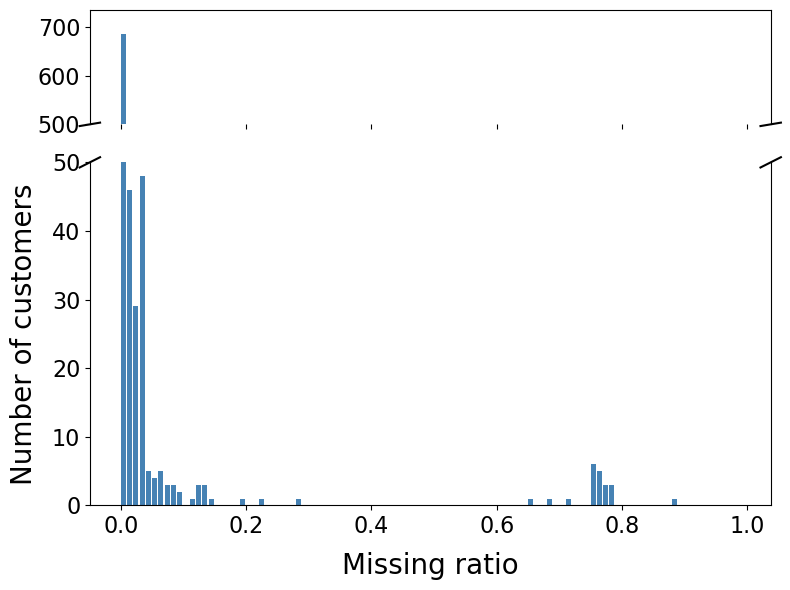

In [9]:
# Extract valid missing_ratio values
valid_ratios = summary_df['missing_ratio'].dropna()

# Bin by 0.01 intervals (0.00 ~ 1.00)
bins = np.arange(0, 1, 0.01)
counts, bin_edges = np.histogram(valid_ratios, bins=bins)

# Draw broken Y-axis
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6), gridspec_kw={'height_ratios': [1, 3]})

# Upper plot (zoomed in on high counts)
ax1.bar(bin_edges[:-1], counts, width=0.008, align='edge', color='steelblue')
ax1.set_ylim(500, max(counts) + 50)
ax1.spines['bottom'].set_visible(False)
ax1.tick_params(labelbottom=False, labelsize=16)
# ax1.set_title("Distribution of Data Missing Ratio per Customer", fontsize=20, pad=20)

# Lower plot (normal range)
ax2.bar(bin_edges[:-1], counts, width=0.008, align='edge', color='steelblue')
ax2.set_ylim(0, 50)
ax2.spines['top'].set_visible(False)
ax2.tick_params(axis='both', which='major', labelsize=16)

# Add break marks
d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

# Set labels
ax2.set_xlabel("Missing ratio", fontsize=20, labelpad=10)
ax2.set_ylabel("Number of customers", fontsize=20, labelpad=10)

plt.tight_layout()
plt.savefig("Figs/missing_ratio_distribution.pdf", format="pdf", dpi=300)
plt.show()


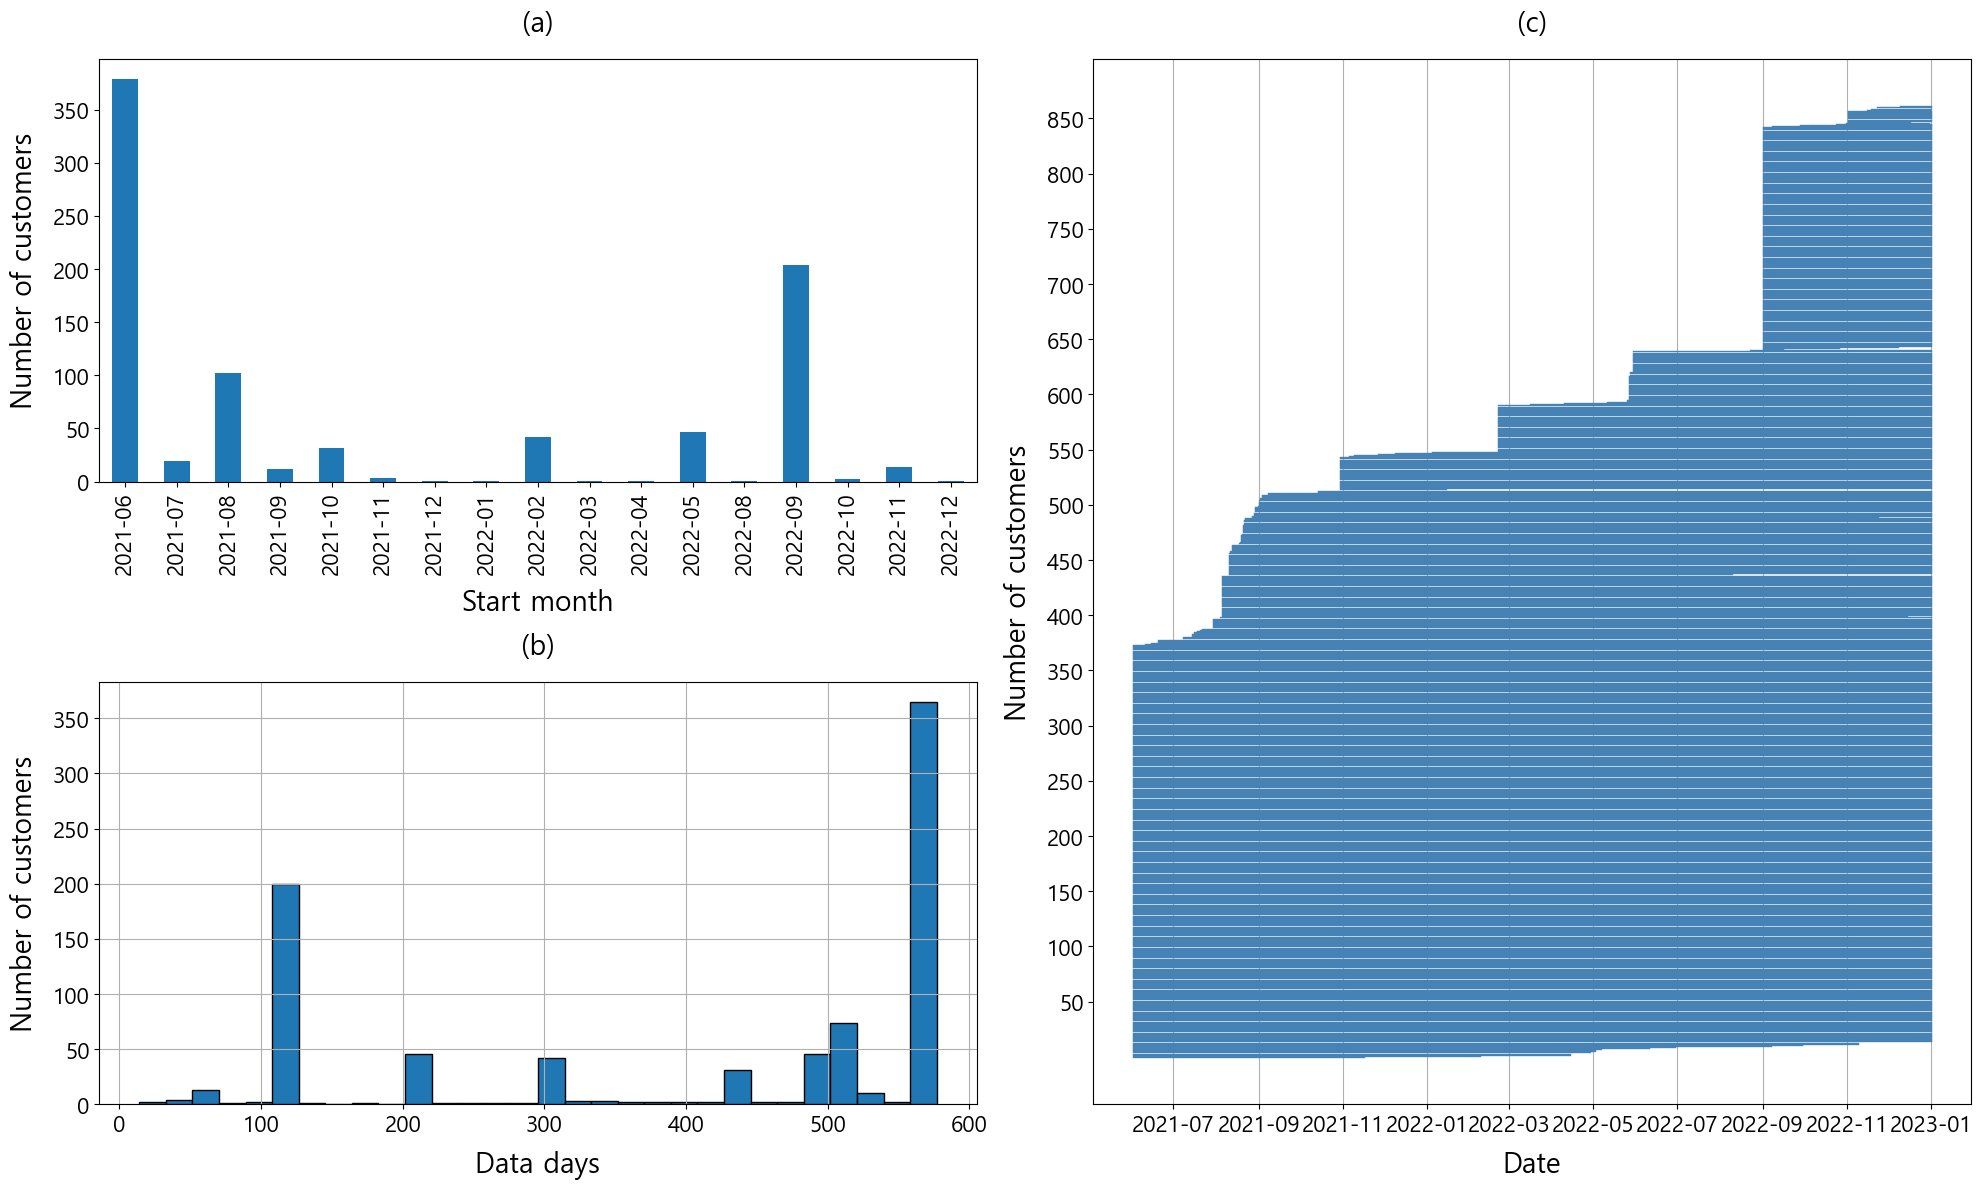

In [44]:
# Create figure with subplots
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1])

# Plot 1: Monthly distribution of data start points
ax1 = fig.add_subplot(gs[0, 0])
summary_df['start_date'].dropna().dt.to_period('M').value_counts().sort_index().plot(
    kind='bar', ax=ax1
)
ax1.set_title('(a)', fontsize=20, pad=20)
ax1.set_xlabel('Start month', fontsize=20, labelpad=10)
ax1.set_ylabel('Number of customers', fontsize=20, labelpad=10)
ax1.tick_params(axis='both', which='major', labelsize=16)

# Plot 2: Distribution of data retention period
ax2 = fig.add_subplot(gs[1, 0])
summary_df['data_days'] = (summary_df['end_date'] - summary_df['start_date']).dt.days
summary_df['data_days'].dropna().hist(bins=30, edgecolor='black', ax=ax2)
ax2.set_title("(b)", fontsize=20, pad=20)
ax2.set_xlabel("Data days", fontsize=20, labelpad=10)
ax2.set_ylabel("Number of customers", fontsize=20, labelpad=10)
ax2.tick_params(axis='both', which='major', labelsize=16)
ax2.grid(True)

# Plot 3: Gantt chart of valid data periods
ax3 = fig.add_subplot(gs[:, 1])
# Convert dates
summary_df['start_date'] = pd.to_datetime(summary_df['start_date'])
summary_df['end_date'] = pd.to_datetime(summary_df['end_date'])

# Sort by start and end dates
sorted_df = summary_df.dropna(subset=['start_date', 'end_date']) \
                      .sort_values(by=['start_date', 'end_date']) \
                      .reset_index(drop=True)

# Plot Gantt chart
bar_height = 0.03
for i, row in sorted_df.iterrows():
    ax3.plot([row['start_date'], row['end_date']], [i, i], color='steelblue', linewidth=1)

# ytick: 50부터 50단위, 마지막 숫자 표시 안함
num_customers = len(sorted_df)
ytick_step = 50
yticks = list(range(ytick_step, num_customers, ytick_step))
ax3.set_yticks(yticks)
ax3.set_yticklabels([str(i) for i in yticks], fontsize=16)
ax3.set_ylabel("Number of customers", fontsize=20, labelpad=10)

ax3.set_xlabel("Date", fontsize=20, labelpad=10)
ax3.set_title("(c)", fontsize=20, pad=20)
ax3.tick_params(axis='both', which='major', labelsize=16)
ax3.grid(True, axis='x')

plt.tight_layout()
fig.savefig("Figs/start_end_date.pdf", format="pdf", dpi=300)
plt.show()


# Pre-processing

In [11]:
# 1. Select customers with less than 5% missing data and valid data period
user_id = np.array(summary_df[(summary_df["missing_ratio"] < 0.05) & (summary_df['data_days'] > 0) & (summary_df['data_days'].notna())]['Customer ID'])

# 2. Dictionary to store processed results
load_filled = {}

# 3. For each customer, perform interpolation and fill long-term missing values with the minimum load
for uid in user_id:
    df = load_raw[uid].copy()
    load = df['load_kWh'].copy()
    
    start_date = df.loc[df['load_kWh'].notna(), 'datetime'].min()
    end_date   = df.loc[df['load_kWh'].notna(), 'datetime'].max()
    
    # Set interpolation range: from the first to the last valid value
    valid_start = df[df['datetime'] == start_date].index[0]
    valid_end   = df[df['datetime'] == end_date].index[0]

    # Initialize the series for processing
    filled = load.copy()

    # Identify missing value segments by index
    is_nan = load.isna()
    gap_start = None

    for i in range(len(load)):
        if i < valid_start or i > valid_end:
            continue  # Do not interpolate outside the valid range
        if is_nan.iloc[i]:
            if gap_start is None:
                gap_start = i
        else:
            if gap_start is not None:
                gap_end = i
                gap_len = gap_end - gap_start

                if gap_len <= 12:
                    # Interpolate short-term missing values (up to 12 intervals)
                    filled.iloc[gap_start:gap_end] = load.iloc[gap_start:gap_end].interpolate(method='linear', limit_direction='both')
                else:
                    # Replace long-term missing segments with the customer's minimum load value
                    min_load = load.dropna().min()
                    filled.iloc[gap_start:gap_end] = min_load
                gap_start = None

    # Save the result
    df['load_kWh_filled'] = filled
    load_filled[uid] = df

Statistical Test Results Summary:

1. t-test results:
Number of customers with significant difference: 11
Number of customers without significant difference: 791


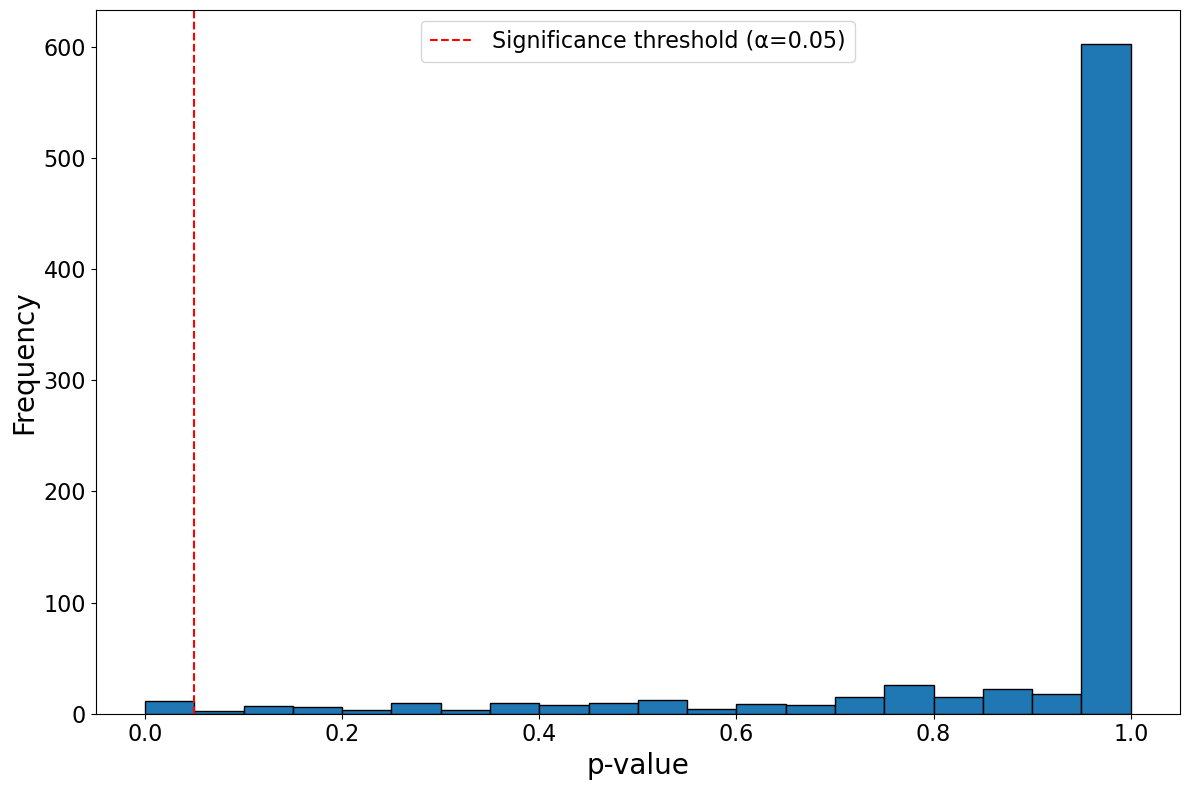

In [12]:
# Dictionary to store results
test_results = {}

for uid in user_id:
    # Extract original and processed data
    original = load_raw[uid]['load_kWh']
    filled = load_filled[uid]['load_kWh_filled']
    
    # Select only non-missing value periods
    original_valid = original[original.notna()]
    filled_valid = filled[filled.notna()]
    
    # Exclude if sample size is too small
    if len(original_valid) < 30 or len(filled_valid) < 30:
        continue
    
    # Perform t-test
    t_stat, t_pval = stats.ttest_ind(original_valid, filled_valid)
    
    # Store results
    test_results[uid] = {
        't_statistic': t_stat,
        't_pvalue': t_pval
    }

# Convert results to DataFrame
test_df = pd.DataFrame.from_dict(test_results, orient='index')

# Interpret results based on significance level 0.05
print("Statistical Test Results Summary:")
print("\n1. t-test results:")
print(f"Number of customers with significant difference: {sum(test_df['t_pvalue'] < 0.05)}")
print(f"Number of customers without significant difference: {sum(test_df['t_pvalue'] >= 0.05)}")

# Visualize results
plt.figure(figsize=(12, 8))

# t-test p-value distribution
plt.hist(test_df['t_pvalue'], bins=20, edgecolor='black')
plt.axvline(x=0.05, color='r', linestyle='--', label='Significance threshold (α=0.05)')
plt.xlabel('p-value', fontsize=20)
plt.ylabel('Frequency', fontsize=20)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.savefig('Figs/t_test_pvalue_histogram.pdf', format="pdf", dpi=300)
plt.show()


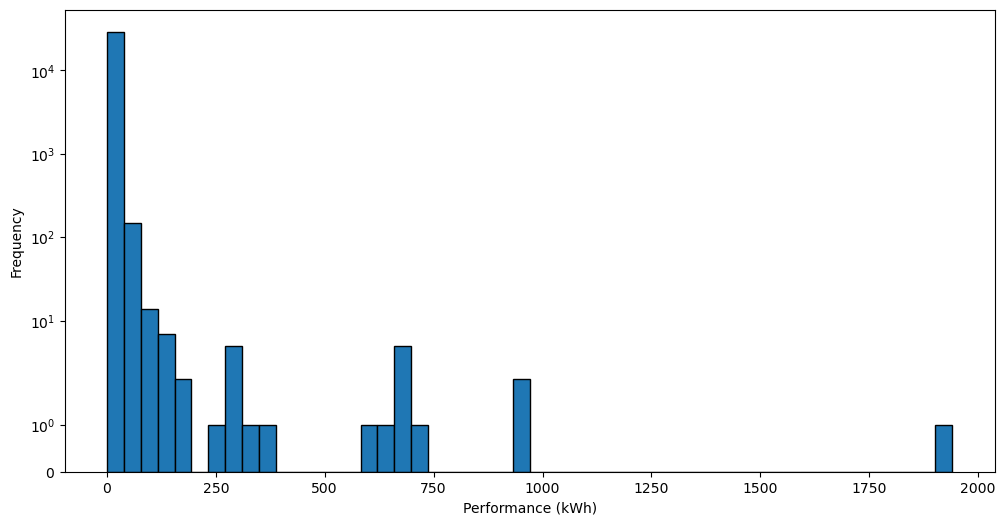

In [13]:
# Analyze the load distribution for all customers (including zeros, with "wave" omitted)

# Collect load data for all customers
all_loads = []
for day, df in performance_raw.items():
    loads = df['Performance (kWh)'].values
    all_loads.extend(loads)

# Visualize histogram
plt.figure(figsize=(12, 6))
plt.hist(all_loads, bins=50, edgecolor='black')
plt.xlabel('Performance (kWh)')
plt.ylabel('Frequency')

# Adjust y-axis scale (wave omitted)
plt.yscale('symlog')  # Change to symmetric log scale to omit the area with many zeros
plt.savefig('Figs/performance_histogram.pdf', format="pdf", dpi=300)
plt.show()

In [14]:
user_id_int = set([int(uid) for uid in user_id])
users = users[users['Customer ID'].isin(user_id_int)]
location_raw = location_raw[location_raw['Customer ID'].isin(user_id_int)]
for day in performance_raw.keys():
    performance_raw[day] = performance_raw[day][performance_raw[day]['Customer ID'].isin(user_id_int)]

# Load Data Analysis

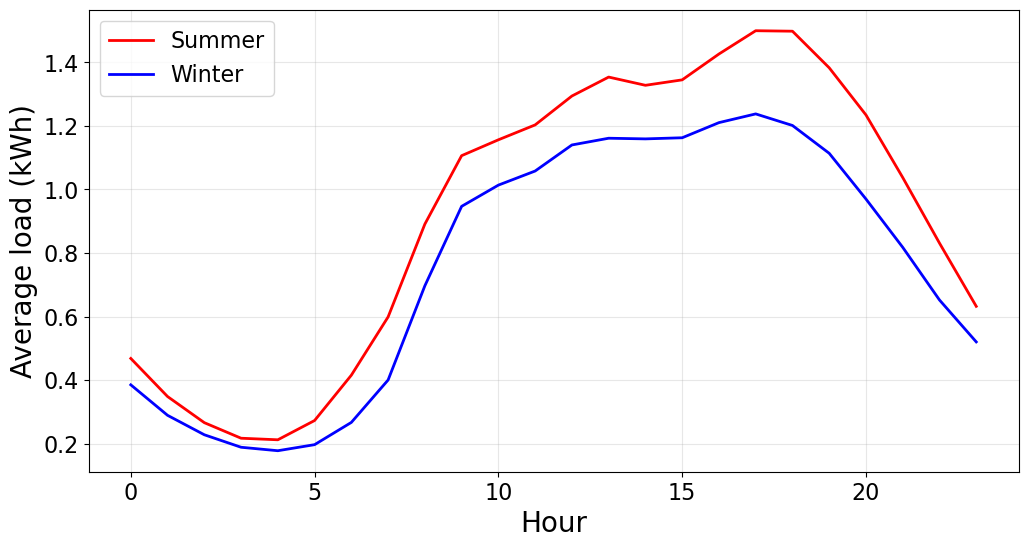

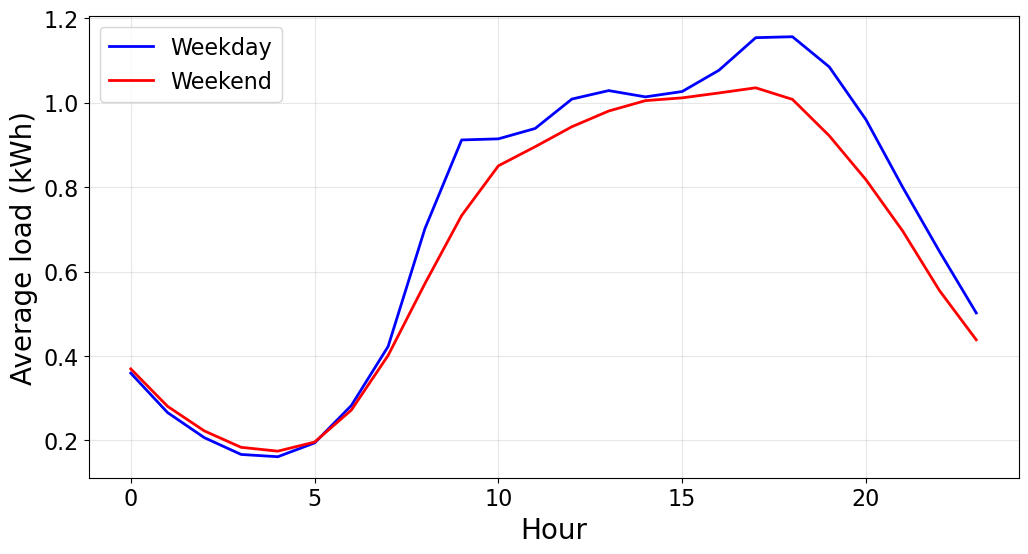

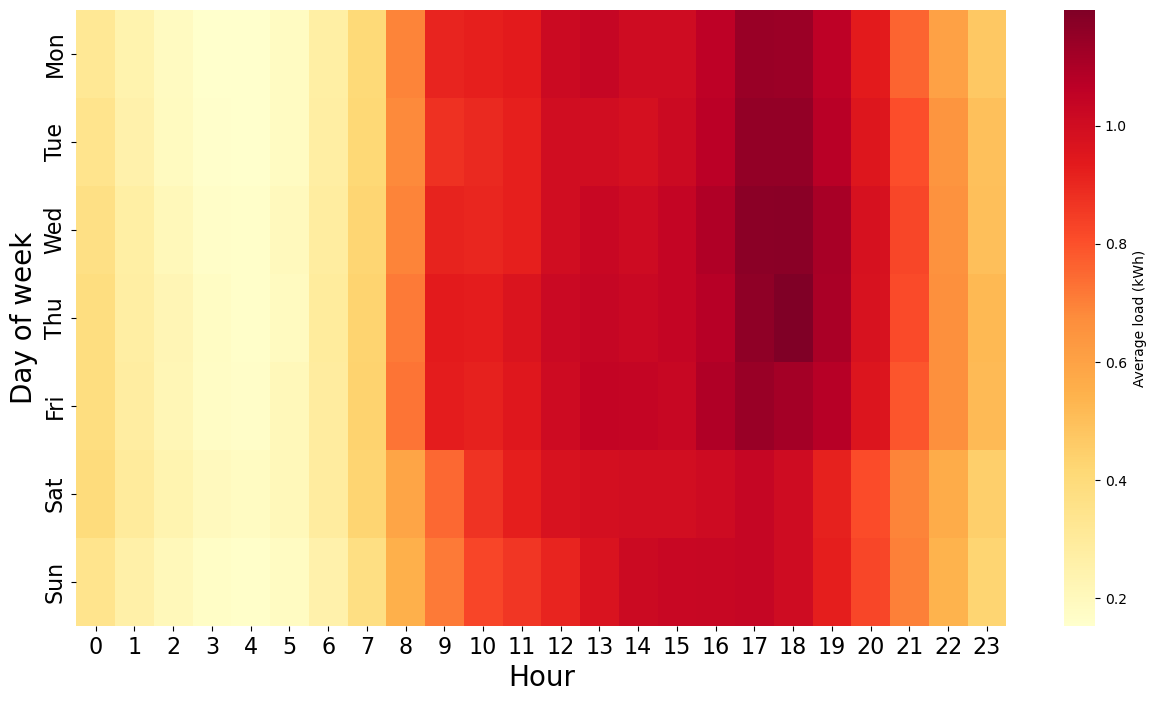

In [16]:
# Summer (July-August) and Winter (December-January) data separation
summer_data = {}
winter_data = {}
for uid, df in load_raw.items():
    df['month'] = df['datetime'].dt.month
    summer_data[uid] = df[df['month'].isin([7,8])]
    winter_data[uid] = df[df['month'].isin([12,1])]

# Weekday/Weekend data separation
weekday_data = {}
weekend_data = {}
for uid, df in load_raw.items():
    df['weekday'] = df['datetime'].dt.weekday
    weekday_data[uid] = df[df['weekday'] < 5]
    weekend_data[uid] = df[df['weekday'] >= 5]

# Function to calculate hourly mean load
def calculate_hourly_means(data_dict):
    hourly_means = {}
    for uid, df in data_dict.items():
        df['hour'] = df['datetime'].dt.hour
        hourly_means[uid] = df.groupby('hour')['load_kWh'].mean()
    return pd.DataFrame(hourly_means).mean(axis=1)

# Seasonal average load curve
summer_curve = calculate_hourly_means(summer_data)
winter_curve = calculate_hourly_means(winter_data)

plt.figure(figsize=(12,6))
plt.plot(summer_curve.index, summer_curve.values, label='Summer', color='red', linewidth=2)
plt.plot(winter_curve.index, winter_curve.values, label='Winter', color='blue', linewidth=2)
plt.xlabel('Hour', fontsize=20)
plt.ylabel('Average load (kWh)', fontsize=20)
plt.legend(fontsize=16)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig('Figs/summer_winter_curve.pdf', format="pdf", dpi=300, bbox_inches='tight')
plt.show()

# Weekday/Weekend average load curve
weekday_curve = calculate_hourly_means(weekday_data)
weekend_curve = calculate_hourly_means(weekend_data)

plt.figure(figsize=(12,6))
plt.plot(weekday_curve.index, weekday_curve.values, label='Weekday', color='blue', linewidth=2)
plt.plot(weekend_curve.index, weekend_curve.values, label='Weekend', color='red', linewidth=2)
plt.xlabel('Hour', fontsize=20)
plt.ylabel('Average load (kWh)', fontsize=20)
plt.legend(fontsize=16)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig('Figs/weekday_weekend_curve.pdf', format="pdf", dpi=300, bbox_inches='tight')
plt.show()

# Daily load pattern heatmap
def create_load_heatmap(data_dict):
    heatmap_data = []
    for uid, df in data_dict.items():
        df['hour'] = df['datetime'].dt.hour
        df['weekday'] = df['datetime'].dt.weekday
        heatmap = df.pivot_table(
            values='load_kWh',
            index='weekday',
            columns='hour',
            aggfunc='mean'
        )
        heatmap_data.append(heatmap)
    return pd.concat(heatmap_data).groupby(level=0).mean()

heatmap = create_load_heatmap(load_raw)
plt.figure(figsize=(15,8))
sns.heatmap(
    heatmap, 
    cmap='YlOrRd', 
    xticklabels=range(24),
    yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
    cbar_kws={'label': 'Average load (kWh)'}
)
plt.xlabel('Hour', fontsize=20)
plt.ylabel('Day of week', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig('Figs/load_heatmap.pdf', format="pdf", dpi=300, bbox_inches='tight')
plt.show()


# DR Performance Analysis

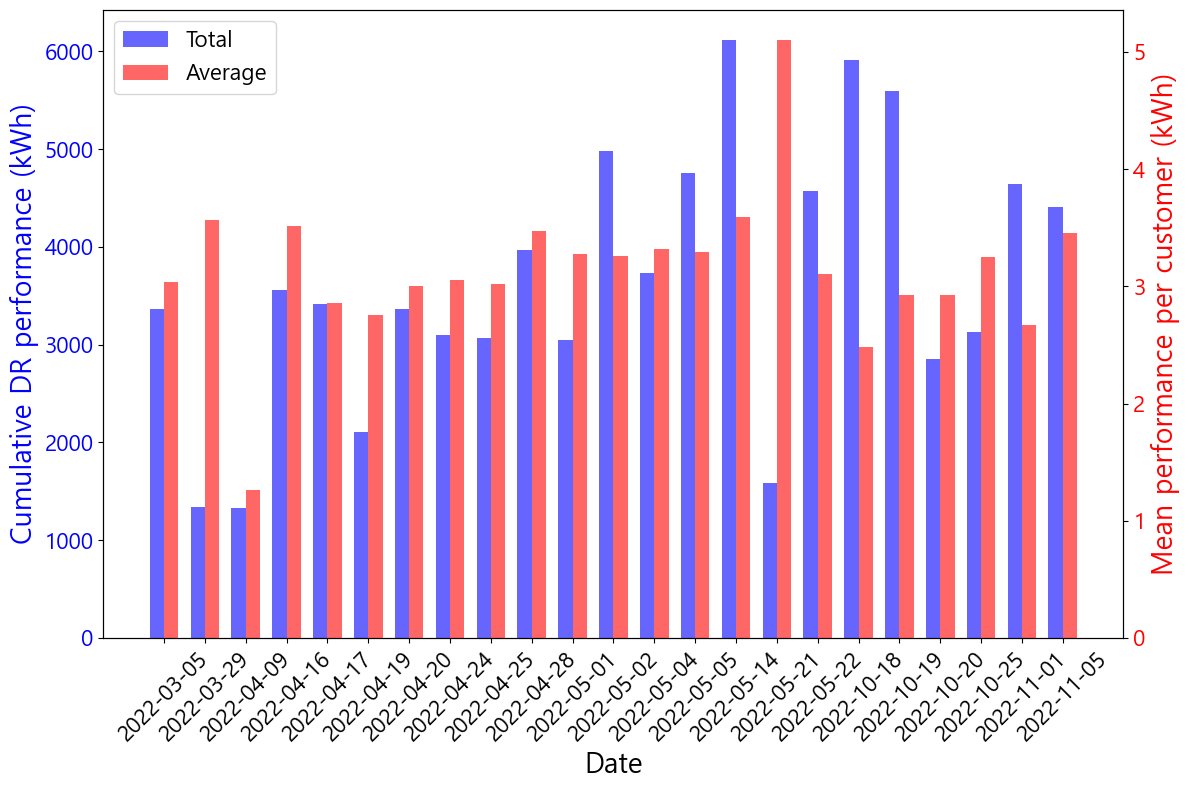

In [46]:
date_results = []
for date_key in performance_raw.keys():
    df = performance_raw[date_key]
    # Filter only customers included in user_id
    df = df[df['Customer ID'].isin(user_id_int)]
    total = df['Performance (kWh)'].sum()
    mean = df['Performance (kWh)'].mean()
    date_results.append({'date': date_key.split('-')[0], 'total': total, 'mean': mean})

date_df = pd.DataFrame(date_results)
date_df['date'] = pd.to_datetime(date_df['date'])
date_df = date_df.sort_values('date')
fig, ax1 = plt.subplots(figsize=(12,8))

# Set x-axis positions
x = np.arange(len(date_df['date']))
width = 0.35

# First bar (Total)
ax1.bar(x - width/2, date_df['total'], width, label='Total', color='blue', alpha=0.6)
ax1.set_xlabel('Date', fontsize=20)
ax1.set_ylabel('Cumulative DR performance (kWh)', color='blue', fontsize=20)
ax1.tick_params(axis='y', labelcolor='blue', labelsize=16)
ax1.tick_params(axis='x', labelsize=16)

# Set x-axis labels - show only date
plt.xticks(x, date_df['date'].dt.strftime('%Y-%m-%d'), rotation=45, fontsize=16)

# Create second y-axis
ax2 = ax1.twinx()
ax2.bar(x + width/2, date_df['mean'], width, label='Average', color='red', alpha=0.6)
ax2.set_ylabel('Mean performance per customer (kWh)', color='red', fontsize=20)
ax2.tick_params(axis='y', labelcolor='red', labelsize=16)

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=16)

plt.tight_layout()
plt.savefig('Figs/dr_performance_analysis.pdf', format="pdf", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# 모든 날짜의 실적을 합쳐서 고객별로 집계
all_perf = []
for date_key in performance_raw.keys():
    df = performance_raw[date_key]
    df = df[df['Customer ID'].isin(user_id_int)]
    df['date'] = date_key.split('-')[0]
    all_perf.append(df[['Customer ID', 'Performance (kWh)', 'date']])

perf_all_df = pd.concat(all_perf)
customer_perf = perf_all_df.groupby('Customer ID')['Performance (kWh)'].agg(['sum', 'mean', 'count'])
customer_perf = customer_perf.sort_values('sum', ascending=False)
print(customer_perf.head())

                  sum       mean  count
Customer ID                            
813647087    1060.425  16.314231     65
812140125     835.900  11.941429     70
813203136     754.001  11.253746     67
812244166     748.605  12.906983     58
813204910     693.312  10.048000     69


In [19]:
# x-axis: Public/Private + Business Type, y-axis: Contract Type + Detailed Type (all in English)
users['X_axis'] = users['Public/Private'] + '/' + users['Business Type']
users['Y_axis'] = users['Contract Type'] + '/' + users['Detailed Type']

pivot_table = users.pivot_table(
    index='Y_axis',
    columns='X_axis',
    values='Customer ID',
    aggfunc='count',
    fill_value=0
)

print("Table. Customer count by Public/Private & Business Type (columns) and Contract Type & Detailed Type (rows)")
display(pivot_table)


Table. Customer count by Public/Private & Business Type (columns) and Contract Type & Detailed Type (rows)


X_axis,Private Charger/Rent-a-car,Public Charger/Privately Owned Charger,Public Charger/Publicly Owned Charger
Y_axis,,,
Commercial Power (Type A) I/High voltage A,0,36,52
Commercial Power (Type A) I/Low voltage,10,207,505
Commercial Power (Type A) II/High voltage A,0,1,0
Commercial Power (Type B)/High voltage A,0,1,0
Residential Power (High Voltage)/High voltage A,0,0,1


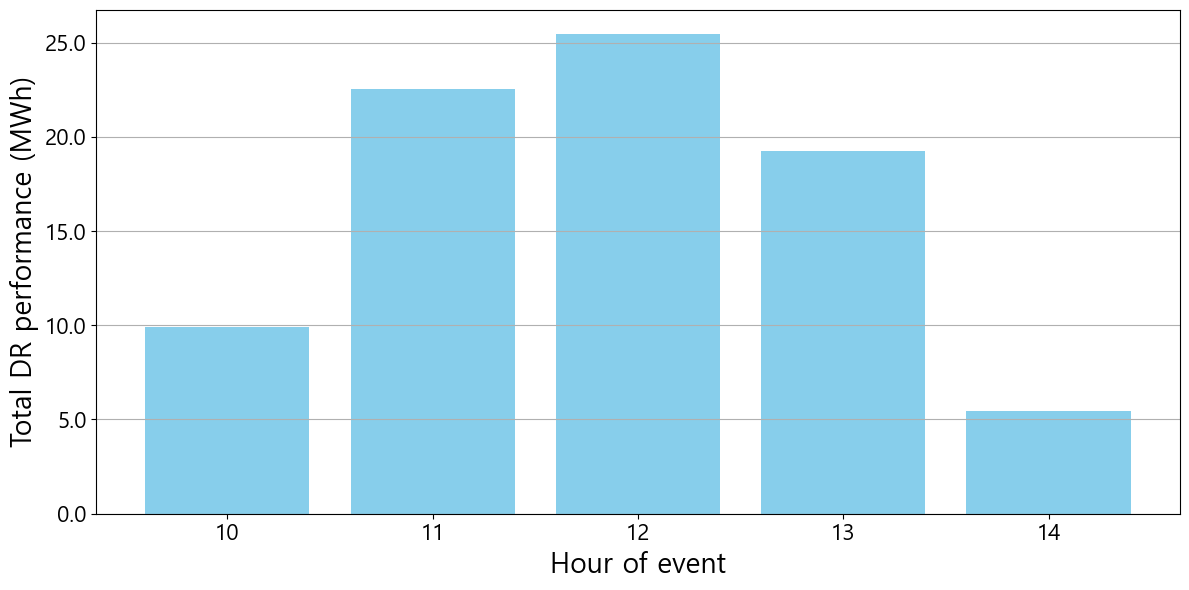

In [47]:
# Combine dataframes for all dates and calculate the total performance by event hour
all_perf_raw = []
for date_key, df in performance_raw.items():
    # If you need to filter by 'Customer ID', uncomment the line below
    # df = df[df['Customer ID'].isin(user_id_int)]
    df = df.copy()
    df['date'] = date_key.split('-')[0]
    all_perf_raw.append(df[['Event Time', 'Performance (kWh)']])

perf_all_raw_df = pd.concat(all_perf_raw, ignore_index=True)

# Calculate the total DR performance by event hour
hourly_sum = perf_all_raw_df.groupby('Event Time')['Performance (kWh)'].sum().reset_index()
hourly_sum = hourly_sum.sort_values('Event Time')

plt.figure(figsize=(12, 6))
plt.bar(hourly_sum['Event Time'], hourly_sum['Performance (kWh)'] / 1000, color='skyblue')
plt.xlabel('Hour of event', fontsize=20)
plt.ylabel('Total DR performance (MWh)', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('Figs/total_dr_performance_by_hour.pdf', format="pdf", dpi=300)
plt.show()

# Lacation Analysis

In [22]:
# Extract unique addresses by location
unique_locations = location_raw['Address'].unique()
print("Number of unique_locations: ", len(unique_locations))

# Calculate the total contract power by full address
location_power = location_raw.groupby('Address')['Contract Power (kW)'].sum().reset_index()
print("\nTotal contract power by address:")
print(location_power.sort_values('Contract Power (kW)', ascending=False).head())

print("\nFull dataset:")
print(location_raw)

Number of unique_locations:  166

Total contract power by address:
                                               Address  Contract Power (kW)
92   Nohyeong-dong, 신제주, Nohyeong-dong, Jeju, 63089...                 2180
22   Donghong-dong, Seogwipo-si, Jeju, 63588, South...                 2019
156                  Yeon-dong, 신제주, Jeju, South Korea                 1416
75             Ido 2(i)-dong, Jeju, 63211, South Korea                 1400
160        Yongdam 2(i)-dong, Jeju, 63161, South Korea                 1256

Full dataset:
     Customer ID Participate Program     Province         City  \
0      813422319              PlusDR  Jeju Island     Jeju-si    
1      813234683              PlusDR  Jeju Island     Jeju-si    
2      813127497              PlusDR  Jeju Island     Jeju-si    
3      813127488              PlusDR  Jeju Island     Jeju-si    
4      813229421              PlusDR  Jeju Island     Jeju-si    
..           ...                 ...          ...          ...   


In [23]:
# Prepare performance data by location
location_perf = perf_all_df.merge(location_raw[['Customer ID', 'Address', 'Contract Power (kW)']], 
                                  left_on='Customer ID', 
                                  right_on='Customer ID', 
                                  how='left',
                                  suffixes=('', '_location'))

# Initialize geocoder
geolocator = Nominatim(user_agent="my_agent")

# Function to convert address to latitude/longitude
def get_coordinates(address):
    try:
        # Specify that the location is in Korea
        location_query = f"{address}"
        location_data = geolocator.geocode(location_query)
        if location_data:
            return location_data.latitude, location_data.longitude
        return None
    except GeocoderTimedOut:
        time.sleep(0.1)
        return get_coordinates(address)

# Store coordinates for each location
location_coords = {}
for loc in unique_locations:
    coords = get_coordinates(loc)
    if coords:
        location_coords[loc] = coords
    time.sleep(1)  # Wait to avoid API rate limit

# Calculate total performance by location
location_sum = location_perf.groupby('Address').agg({
    'Performance (kWh)': 'sum'
}).reset_index()

# Add latitude/longitude information
location_sum['Latitude'] = location_sum['Address'].map(lambda x: location_coords.get(x, (None, None))[0])
location_sum['Longitude'] = location_sum['Address'].map(lambda x: location_coords.get(x, (None, None))[1])

In [24]:
location_sum = location_sum.merge(location_power[['Address', 'Contract Power (kW)']], on='Address', how='left')

In [25]:
# Combine the performance and contracted power for addresses with the same latitude and longitude
location_sum = location_sum.groupby(['Latitude', 'Longitude']).agg({
    'Address': 'first',  # Keep the first address
    'Performance (kWh)': 'sum',  # Sum of performance
    'Contract Power (kW)': 'sum'  # Sum of contracted power
}).reset_index()

location_sum

,Latitude,Longitude,Address,Performance (kWh),Contract Power (kW)
0,33.169740,126.271360,"Gapa-ri, Daejeong, Seogwipo-si, Jeju, 63515, S...",14.373,7
1,33.222909,126.253432,"Hamo-ri, Daejeong, Seogwipo-si, Jeju, 63507, S...",2280.829,599
2,33.223658,126.271496,"Sangmo-ri, Daejeong, Seogwipo-si, Jeju, 63510,...",477.563,150
3,33.231710,126.306570,"Sagye-ri, Andeok, Seogwipo-si, Jeju, 63528, So...",934.485,157
4,33.240160,126.380600,"Haye-dong, Yerae-dong, Seogwipo-si, Jeju, 6353...",0.000,28
...,...,...,...,...,...
149,33.546437,126.716736,"Dongbok-ri, Gujwa, Jeju, South Korea",96.444,50
150,33.547240,126.649550,"Sinheung-ri, Jocheon, Jeju, 63332, South Korea",85.398,50
151,33.547942,126.695232,"Bukchon-ri, Jocheon, Jeju, South Korea",0.000,28
152,33.550120,126.757900,"Gimnyeong-ri, Gujwa, Jeju, 63357, South Korea",341.782,335


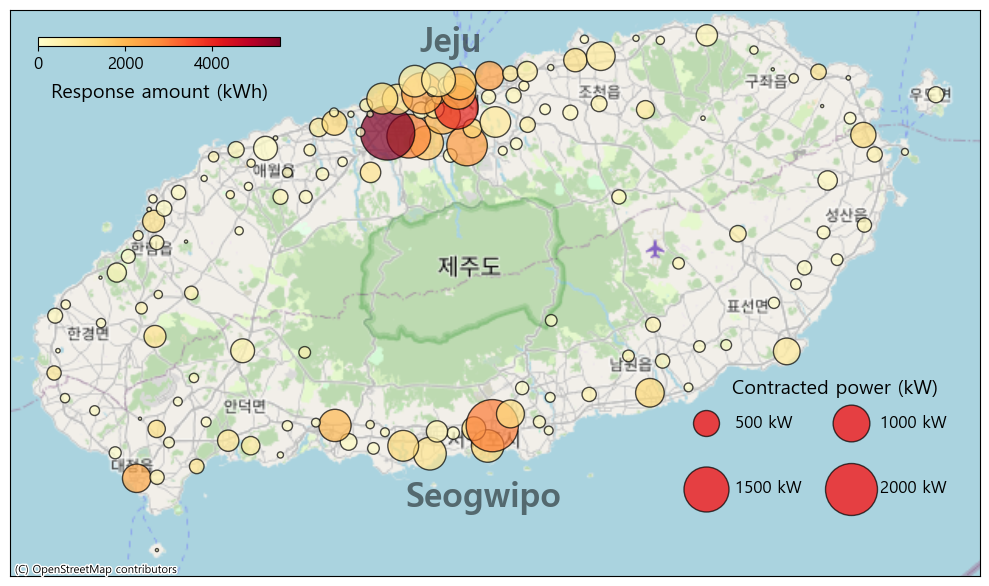

In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
from matplotlib.patches import Patch, Circle
from matplotlib.lines import Line2D

gdf_filtered = location_sum[location_sum['Latitude'] < 33.95].copy()

geometry = [Point(xy) for xy in zip(gdf_filtered['Longitude'], gdf_filtered['Latitude'])]
gdf = gpd.GeoDataFrame(gdf_filtered, geometry=geometry, crs="EPSG:4326")

gdf_web = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 6))

marker_scale = 0.7
gdf_web['marker_size'] = gdf_web['Contract Power (kW)'] * marker_scale

scatter = gdf_web.plot(
    ax=ax,
    column='Performance (kWh)',
    cmap='YlOrRd',
    markersize=gdf_web['marker_size'],
    legend=False,
    alpha=0.7,
    edgecolor='k'
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

size_values = np.array([500, 1000, 1500, 2000])
legend_marker_sizes = size_values * marker_scale

legend_circles = [
    Line2D([0], [0], marker='o', color='w', label=f"{v} kW",
           markerfacecolor='red', markersize=np.sqrt(ms), alpha=0.7, markeredgecolor='k')
    for v, ms in zip(size_values, legend_marker_sizes)
]

import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

norm = plt.Normalize(gdf_web['Performance (kWh)'].min(), gdf_web['Performance (kWh)'].max())
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
sm._A = []

cbar_ax = inset_axes(ax, width="25%", height="1.5%", loc='upper left', borderpad=2)
cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Response amount (kWh)', fontsize=14, labelpad=8)
cbar.ax.tick_params(labelsize=12)

from matplotlib.legend import Legend

legend_handles = legend_circles
legend_labels = [f"{v} kW" for v in size_values]

legend_ax = inset_axes(ax, width="30%", height="23%", loc='lower right', borderpad=3)
legend_ax.axis('off')

label_x_offset = 0.3
row_y_base = 0.85
row_y_gap = 0.5
for i, handle in enumerate(legend_handles):
    row = i // 2
    col = i % 2
    legend_ax.add_line(Line2D([0.2 + col*0.5], [row_y_base - row*row_y_gap], marker='o', color='w',
                              markerfacecolor='red', markersize=np.sqrt(legend_marker_sizes[i]),
                              alpha=0.7, markeredgecolor='k', linestyle='None'))
    legend_ax.text(label_x_offset + col*0.5, row_y_base - row*row_y_gap, legend_labels[i], va='center', fontsize=12)

legend_ax.text(1.0, 1.08, "Contracted power (kW)", fontsize=14, ha='right')

jeju_lat = 33.4996
jeju_lon = 126.5312
seogwipo_lat = 33.2540
seogwipo_lon = 126.5601

from pyproj import Transformer
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
jeju_x, jeju_y = transformer.transform(jeju_lon, jeju_lat)
seogwipo_x, seogwipo_y = transformer.transform(seogwipo_lon, seogwipo_lat)

jeju_y_shifted = jeju_y + 6000
seogwipo_y_shifted = seogwipo_y - 6000

ax.text(jeju_x, jeju_y_shifted, 'Jeju', fontsize=24, color='black', fontweight='bold', alpha=0.5, ha='center', va='center')
ax.text(seogwipo_x, seogwipo_y_shifted, 'Seogwipo', fontsize=24, color='black', fontweight='bold', alpha=0.5, ha='center', va='center')

ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()
plt.savefig('Figs/dr_location_map.pdf', format="pdf", dpi=300)
plt.show()

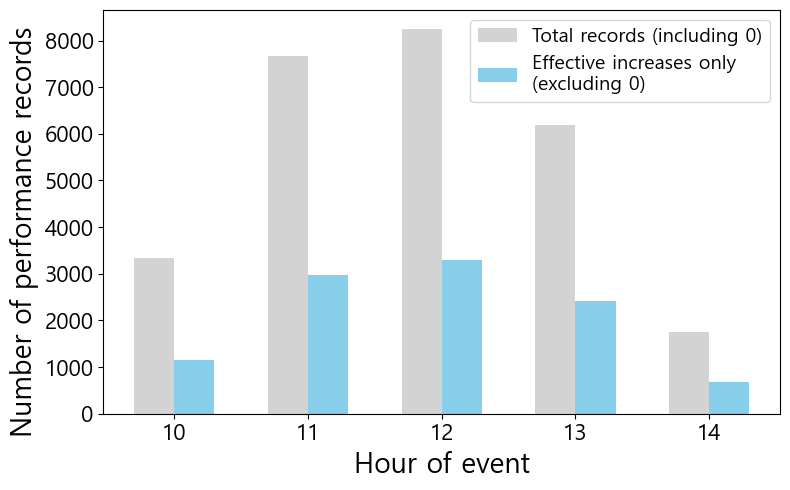

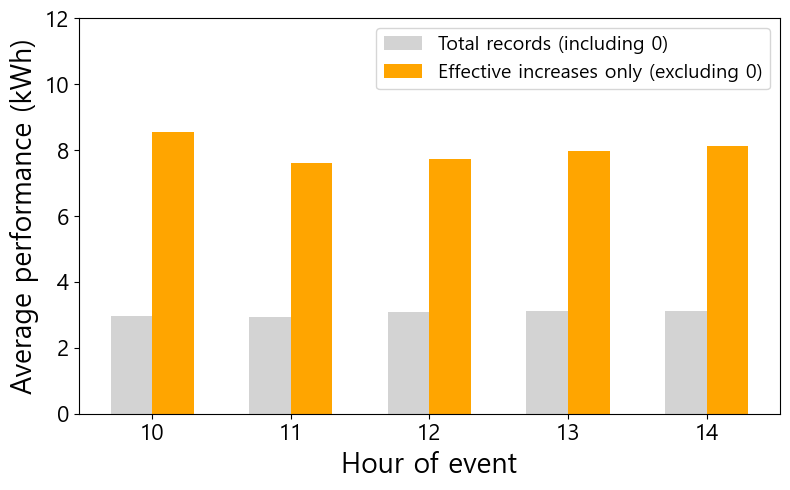

In [56]:
# Extract data from 10:00 to 14:00 in performance_raw,
# and compare the number of events and average performance by hour for
# 1) all records (including Performance (kWh) == 0), and 2) only records where Performance (kWh) > 0.

dfs_all = []
dfs_pos = []
for df in performance_raw.values():
    # Check if both 'Event Time' and 'Performance (kWh)' columns exist
    if 'Event Time' in df.columns and 'Performance (kWh)' in df.columns:
        temp = df[df['Event Time'].notna() & df['Performance (kWh)'].notna()].copy()
        temp['Event Time'] = temp['Event Time'].astype(int)
        temp = temp[(temp['Event Time'] >= 10) & (temp['Event Time'] <= 14)]
        dfs_all.append(temp)
        temp_pos = temp[temp['Performance (kWh)'] > 0]
        dfs_pos.append(temp_pos)

# Concatenate dataframes
if len(dfs_all) > 0:
    dr_all = pd.concat(dfs_all, ignore_index=True)
else:
    dr_all = pd.DataFrame(columns=['Customer ID', 'Event Date', 'Event Time', 'Performance (kWh)'])

if len(dfs_pos) > 0:
    dr_pos = pd.concat(dfs_pos, ignore_index=True)
else:
    dr_pos = pd.DataFrame(columns=['Customer ID', 'Event Date', 'Event Time', 'Performance (kWh)'])

# Figure X: Number of DR events by hour (including/excluding zeros)
event_count_by_hour_all = dr_all.groupby('Event Time').size()
event_count_by_hour_pos = dr_pos.groupby('Event Time').size()

import numpy as np
import matplotlib.pyplot as plt

x_ticks = np.arange(10, 15)
plt.figure(figsize=(8,5))
plt.bar(x_ticks-0.15, [event_count_by_hour_all.get(x,0) for x in x_ticks], width=0.3, 
        label='Total records (including 0)', color='lightgray')
plt.bar(x_ticks+0.15, [event_count_by_hour_pos.get(x,0) for x in x_ticks], width=0.3, 
        label='Effective increases only \n(excluding 0)', color='skyblue')
plt.xlabel('Hour of event', fontsize=20)
plt.ylabel('Number of performance records    ', fontsize=20)
plt.xticks(x_ticks, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig('Figs/figure_x.pdf', format="pdf", dpi=300)
plt.show()

# Figure Y: Average performance per event by hour (including/excluding zeros)
avg_performance_by_hour_all = dr_all.groupby('Event Time')['Performance (kWh)'].mean()
avg_performance_by_hour_pos = dr_pos.groupby('Event Time')['Performance (kWh)'].mean()

plt.figure(figsize=(8,5))
plt.bar(x_ticks-0.15, [avg_performance_by_hour_all.get(x,0) for x in x_ticks], width=0.3, 
        label='Total records (including 0)', color='lightgray')
plt.bar(x_ticks+0.15, [avg_performance_by_hour_pos.get(x,0) for x in x_ticks], width=0.3, 
        label='Effective increases only (excluding 0)', color='orange')
plt.xlabel('Hour of event', fontsize=20)
plt.ylabel('Average performance (kWh)', fontsize=20)
plt.xticks(x_ticks, fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0, 12)  # Set y-axis max to 12
plt.legend(fontsize=14, loc='upper right')  # Move legend to upper right
plt.tight_layout()
plt.savefig('Figs/figure_y.pdf', format="pdf", dpi=300)
plt.show()

In [31]:
import logging, re
from pathlib import Path
from datetime import datetime
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, holidays, warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'

DIR = Path(r'C:\Users\USER\OneDrive\바탕 화면\P2M\scientific data\제출용\Data_2022')
CSV = DIR / 'Public_Data.csv'
df = pd.read_csv(CSV, encoding='cp949', low_memory=False)

PAT = {'start_date':r'시작.*(일자|날짜)','start_hour':r'시작.*시$','start_ms':r'시작.*(분|분초)',
       'end_date':r'종료.*(일자|날짜)','end_hour':r'종료.*시$','end_ms':r'종료.*(분|분초)',
       'energy':r'충전.*량'}
df = df.rename(columns={v:k for k,p in PAT.items() for v in df.columns if re.search(p,v)})

def mk_dt(d,h,ms):
    base = pd.to_datetime(d, errors='coerce') + pd.to_timedelta(h,'h')
    mmss = (ms.astype(str).str.split(':').str[:2]
            .apply(lambda x: pd.Series(x,index=['m','s'])).astype(float).fillna(0))
    return base + pd.to_timedelta(mmss['m'],'m') + pd.to_timedelta(mmss['s'],'s')

df['start_dt'] = mk_dt(df['start_date'], df['start_hour'], df['start_ms'])
df['end_dt']   = mk_dt(df['end_date'],   df['end_hour'],   df['end_ms'])
df['kWh']      = pd.to_numeric(df['energy'], errors='coerce')
df = df.dropna(subset=['start_dt','end_dt','kWh'])
df = df[df['end_dt'] > df['start_dt']]
df['dur_h'] = (df['end_dt']-df['start_dt']).dt.total_seconds()/3600
df = df[df['dur_h'] > 0]
df['Pavg'] = df['kWh']/df['dur_h']


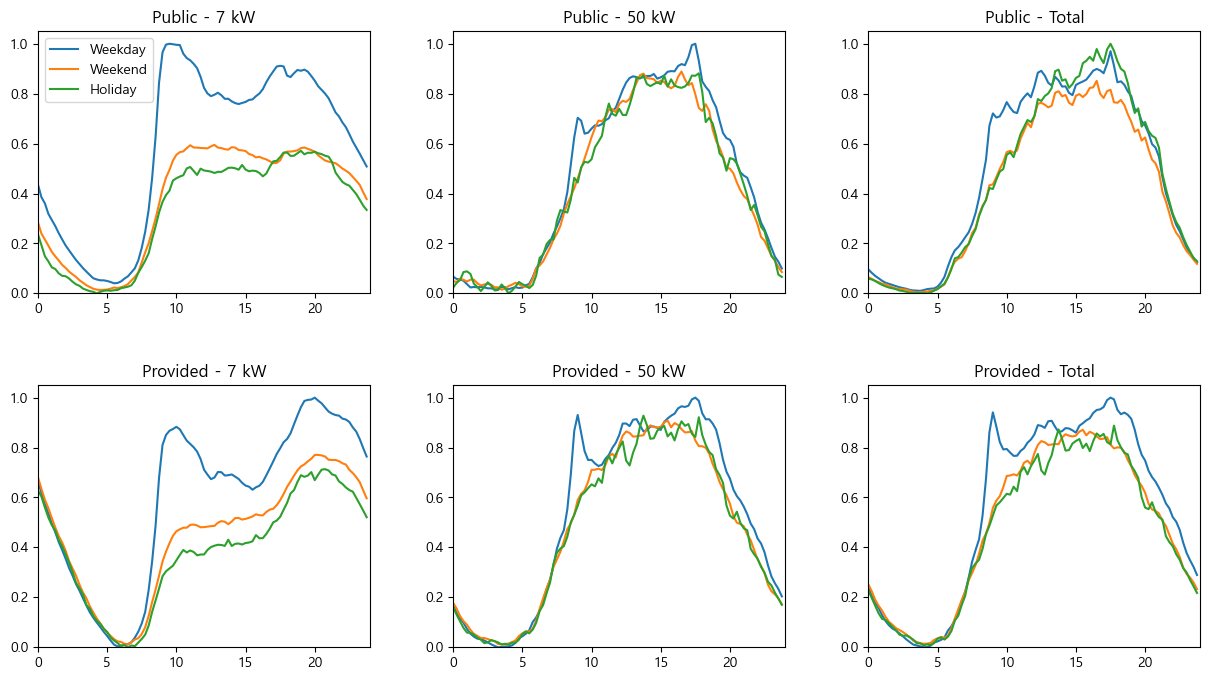

In [32]:
pret  = {}
data_dir = DIR/'PlusDR_Participant_Load_Data'
for _,r in users.iterrows():
    uid=r['Customer ID']; cont=r['Contract Power (kW)']
    fp=data_dir/f'0{uid}.csv'
    try:
        base=pd.read_csv(fp, skiprows=[0], index_col=0)
        base[base>cont/2]=np.nan
        pret[uid]=base.dropna(thresh=80).interpolate(axis=1)
    except: pass

prov_dates=[]
for b in pret.values():
    prov_dates.extend(b.index.tolist())
prov_min=datetime.strptime(str(min(prov_dates)),"%Y%m%d").date()
prov_max=datetime.strptime(str(max(prov_dates)),"%Y%m%d").date()
df=df[(df['start_dt'].dt.date>=prov_min)&(df['start_dt'].dt.date<=prov_max)]

kr_holidays = holidays.KR(years=range(df['start_dt'].dt.year.min(),
                                      df['start_dt'].dt.year.max()+1))
def day_kind(ts):
    if ts.date() in kr_holidays: return 'Holiday'
    return 'Weekend' if ts.weekday() >= 5 else 'Weekday'
df['dayKind'] = df['start_dt'].apply(day_kind)

slow = df[df['Pavg'].between(5,10)]
fast = df[df['Pavg'].between(40,60)]

def quarter_load(dsub):
    rec=[]
    for s,e,eng,k in dsub[['start_dt','end_dt','kWh','dayKind']].itertuples(False):
        tot=(e-s).total_seconds(); cur=s
        while cur<e:
            nxt=(cur.floor('15T')+pd.Timedelta(minutes=15))
            if nxt>e:nxt=e
            slot=((cur.hour*60+cur.minute)//15)
            rec.append((k,slot,cur.date(),eng*(nxt-cur).total_seconds()/tot))
            cur=nxt
    load=(pd.DataFrame(rec,columns=['kind','slot','date','kWh'])
          .groupby(['date','kind','slot'])['kWh'].sum()
          .groupby(['kind','slot']).mean()
          .unstack('kind')
          .reindex(range(96)))
    return load

load_slow_pub  = quarter_load(slow)
load_fast_pub  = quarter_load(fast)
load_total_pub = quarter_load(df)

cont={7:[],14:[],50:[]}
for uid in pret:
    try:
        pwr=users.loc[users['Customer ID']==uid].iloc[0,5]
        if pwr in cont: cont[pwr].append(uid)
    except: pass

holiday=[20210101,20210211,20210212,20210301,20210505,20210519,20210606,
         20210815,20210816,20210920,20210921,20210922,20211003,20211004,
         20211009,20211011,20211225,20220101,20220131,20220201,20220202,
         20220301,20220309,20220505,20220508,20220601,20220606,20220815,
         20220909,20220910,20220911,20220912,20221003,20221009,20221010,20221225]

def to96(s):
    v=s.values.astype(float)
    if len(v)==96:return v
    xo=np.linspace(0,1,len(v),endpoint=False)
    xn=np.linspace(0,1,96,endpoint=False)
    return np.interp(xn,xo,v)

def collect(uids,ratio):
    wd,we,hd=[],[],[]
    for uid in uids:
        for ind,row in pret[uid].iterrows():
            vec=to96(row/ratio)
            wk=datetime.strptime(str(ind),'%Y%m%d').weekday()
            if ind in holiday:      hd.append(vec)
            elif wk>=5:             we.append(vec)
            else:                   wd.append(vec)
    return wd,we,hd

P_WD,P_WE,P_HD=[],[],[]
for uid in cont[7]:
    w,d,h=collect([uid],1); P_WD+=w; P_WE+=d; P_HD+=h
for uid in cont[14]:
    w,d,h=collect([uid],2); P_WD+=w*2; P_WE+=d*2; P_HD+=h*2
R_WD,R_WE,R_HD=collect(cont[50],1)

def nanmean96(lst): return np.zeros(96) if not lst else np.nanmean(np.stack(lst),axis=0)

kepco_slow={'Weekday':nanmean96(P_WD),'Weekend':nanmean96(P_WE),'Holiday':nanmean96(P_HD)}
kepco_fast={'Weekday':nanmean96(R_WD),'Weekend':nanmean96(R_WE),'Holiday':nanmean96(R_HD)}
kepco_total={k:(kepco_slow[k]+kepco_fast[k])/2 for k in kepco_slow}

def mm_norm(d):
    if isinstance(d,pd.DataFrame):
        mn,mx=np.nanmin(d.values),np.nanmax(d.values)
        return ((d-mn)/(mx-mn)).fillna(0) if mx>mn else d*0
    v=np.concatenate(list(d.values()))
    mn,mx=np.nanmin(v),np.nanmax(v)
    return {k:np.nan_to_num((v-mn)/(mx-mn) if mx>mn else np.zeros_like(v)) for k,v in d.items()}

load_slow_pub_n  = mm_norm(load_slow_pub)
load_fast_pub_n  = mm_norm(load_fast_pub)
load_total_pub_n = mm_norm(load_total_pub)
kepco_slow_n     = mm_norm(kepco_slow)
kepco_fast_n     = mm_norm(kepco_fast)
kepco_total_n    = mm_norm(kepco_total)

fig,axes=plt.subplots(2,3,figsize=(15,8))
plt.subplots_adjust(wspace=0.25,hspace=0.35)
colors={'Weekday':'#1f77b4','Weekend':'#ff7f0e','Holiday':'#2ca02c'}
x96=np.linspace(0,24,96,endpoint=False)

pub=[(load_slow_pub_n,'Public - 7 kW'),
     (load_fast_pub_n,'Public - 50 kW'),
     (load_total_pub_n,'Public - Total')]
kep=[(kepco_slow_n,'Provided - 7 kW'),
     (kepco_fast_n,'Provided - 50 kW'),
     (kepco_total_n,'Provided - Total')]

for i,(d,title) in enumerate(pub):
    ax=axes[0,i]
    for k in colors: ax.plot(x96,d[k].values,lw=1.5,color=colors[k],label=k)
    ax.set_title(title); ax.set_xlim(0,24); ax.set_ylim(0,1.05)
    if i==0: ax.legend()

for i,(d,title) in enumerate(kep):
    ax=axes[1,i]
    for k in colors: ax.plot(x96,d[k],lw=1.5,color=colors[k],label=k)
    ax.set_title(title); ax.set_xlim(0,24); ax.set_ylim(0,1.05)

fig.savefig('Figs/figure_kepco_pub.pdf', format="pdf", dpi=300)
plt.show()